IMPORT LIBRARIES

In [4]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

load dataset

In [5]:
df = pd.read_csv(r"C:\Users\Riddhi\Desktop\projectssss\supply_chain_data.csv")

BASIC INFO

In [6]:
print(df.head())
print(df.info())
print(df.describe())

  Product type   SKU      Price  Availability  Number of products sold  \
0     haircare  SKU0  69.808006            55                      802   
1     skincare  SKU1  14.843523            95                      736   
2     haircare  SKU2  11.319683            34                        8   
3     skincare  SKU3  61.163343            68                       83   
4     skincare  SKU4   4.805496            26                      871   

   Revenue generated Customer demographics  Stock levels  Lead times  \
0        8661.996792            Non-binary            58           7   
1        7460.900065                Female            53          30   
2        9577.749626               Unknown             1          10   
3        7766.836426            Non-binary            23          13   
4        2686.505152            Non-binary             5           3   

   Order quantities  ...  Location Lead time  Production volumes  \
0                96  ...    Mumbai        29          

DATA CLEANING

In [8]:
df.columns = df.columns.str.strip()   # remove extra spaces
df = df.drop_duplicates()

FILL MISSING VALUES INSTEAD OF DROPPING ALL

In [9]:
df.fillna(method='ffill', inplace=True)

C:\Users\Riddhi\AppData\Local\Temp\ipykernel_22968\3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


CHECK COLUMNS 

In [10]:
print("Columns:", df.columns)

Columns: Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='object')


DATA ANALYSIS

In [11]:
group_data = df.groupby("Product type")["Number of products sold"].sum()
print(group_data)


Product type
cosmetics    11757
haircare     13611
skincare     20731
Name: Number of products sold, dtype: int64


TOP 5 RECORDS

In [12]:
top_products = df.nlargest(5, "Number of products sold")
print(top_products)


   Product type    SKU      Price  Availability  Number of products sold  \
10     skincare  SKU10  15.707796            11                      996   
94    cosmetics  SKU94   3.037689            97                      987   
9      skincare   SKU9  64.015733            35                      980   
36     skincare  SKU36   9.813003            34                      963   
37     skincare  SKU37  23.399845             5                      963   

    Revenue generated Customer demographics  Stock levels  Lead times  \
10        2330.965802            Non-binary            51          13   
94        7888.356547               Unknown            77          26   
9         4971.145988               Unknown            14          27   
36        7573.402458                Female            18          23   
37        2438.339930                Female            25           8   

    Order quantities  ...  Location Lead time  Production volumes  \
10                80  ...   Kolkata

ADVANCED ANALYSIS

In [13]:
avg_sales = df.groupby("Product type")["Number of products sold"].mean()
print(avg_sales)

Product type
cosmetics    452.192308
haircare     400.323529
skincare     518.275000
Name: Number of products sold, dtype: float64


VISUALIZATION

BAR CHART

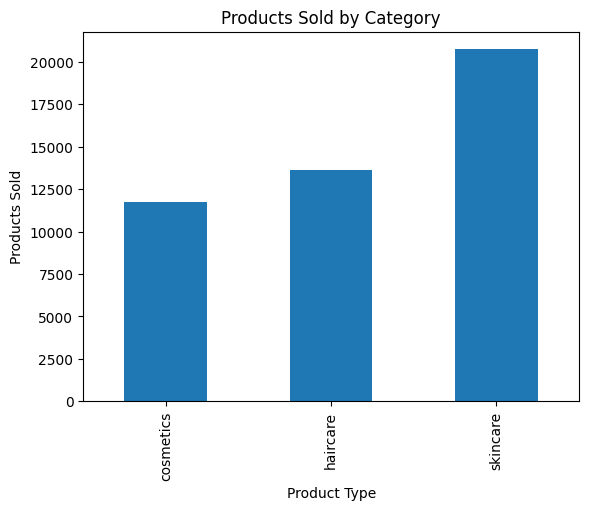

In [14]:
group_data.plot(kind='bar')
plt.title("Products Sold by Category")
plt.xlabel("Product Type")
plt.ylabel("Products Sold")
plt.show()

LINE CHART

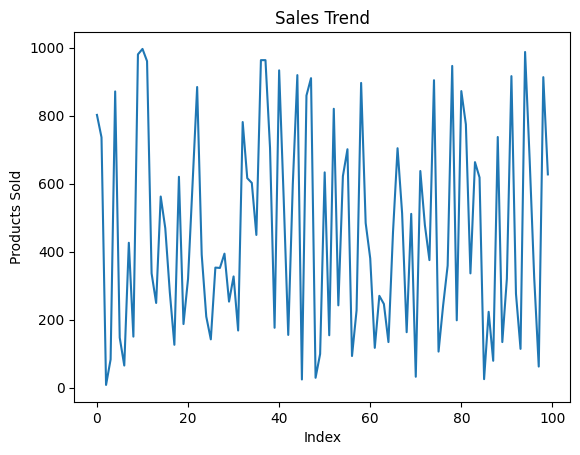

In [15]:
df["Number of products sold"].plot(kind='line')
plt.title("Sales Trend")
plt.xlabel("Index")
plt.ylabel("Products Sold")
plt.show()

HISTOGRAM

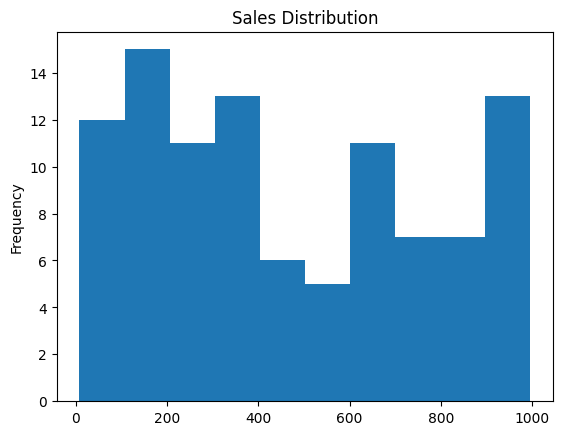

In [16]:
df["Number of products sold"].plot(kind='hist', bins=10)
plt.title("Sales Distribution")
plt.show()

CORRELATION

In [17]:
print(df.corr(numeric_only=True))

                            Price  Availability  Number of products sold  \
Price                    1.000000      0.019083                 0.005739   
Availability             0.019083      1.000000                 0.087496   
Number of products sold  0.005739      0.087496                 1.000000   
Revenue generated        0.038424     -0.075170                -0.001641   
Stock levels             0.078261     -0.025900                 0.022189   
Lead times               0.044855      0.170439                -0.046419   
Order quantities         0.095819      0.143769                 0.015992   
Shipping times           0.071942     -0.051377                 0.087315   
Shipping costs           0.058543     -0.044179                 0.044285   
Lead time                0.152185     -0.156669                 0.041230   
Production volumes      -0.124575      0.050134                 0.187945   
Manufacturing lead time -0.301313      0.065333                -0.048939   
Manufacturin

SAVE CLEAN 

In [18]:
df.to_csv("cleaned_data.csv", index=False)